In [1]:
import matplotlib.pyplot as plt
import numpy as np
import joblib
import torch
from torch.utils.data import TensorDataset
from torch import nn

from net_utils import load_from_file
import plotting
import networks
import importlib
import os


c:\Users\ET USER\Documents\Caltech\CNS 186\Project\hebbff\plotting.py:3: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  import scipy.stats as stats


In [16]:
for netFile, imgsFile, label in [
        ('publish/conv/HebbNet[50,16,1]_train=cur1_incr=plus1_w1init=randn_b1init=scalar_w2init=scalar.pkl',
                           'publish\conv\BradyOliva2008_UniqueObjects_ResNet18.pkl', 'featurize'),
]:

    folder, filename = os.path.split(netFile)
    idx = filename.find('[')
    if idx == -1:
        idx = filename.find('_')
    if idx == -1:
         raise ValueError('Invalid filename')  
    NetClass = getattr(importlib.import_module('networks'), filename[:idx])
    print(NetClass)   

    net = load_from_file(netFile)
    N,d = net.w1.shape
    print(net.hist['increment_R'][-1][1])
    x = torch.randn(10, d)
    check = net.featurizer(x).detach()



<class 'networks.HebbNet'>
17


AttributeError: 'HebbNet' object has no attribute 'featurizer'

### Plot generalization after training done

R=1, truePos=1.000, falsePos=0.956, acc=0.355=0.350, (chance=0.680)
R=2, truePos=0.985, falsePos=0.941, acc=0.365=0.360, (chance=0.675)
R=3, truePos=1.000, falsePos=0.943, acc=0.330=0.335, (chance=0.705)
R=4, truePos=1.000, falsePos=0.946, acc=0.390=0.385, (chance=0.650)
R=6, truePos=1.000, falsePos=0.920, acc=0.365=0.365, (chance=0.690)
R=8, truePos=1.000, falsePos=0.964, acc=0.330=0.330, (chance=0.695)
R=11, truePos=1.000, falsePos=0.925, acc=0.391=0.382, (chance=0.668)
R=15, truePos=0.945, falsePos=0.921, acc=0.400=0.393, (chance=0.637)
R=20, truePos=0.961, falsePos=0.941, acc=0.350=0.345, (chance=0.682)
R=26, truePos=0.948, falsePos=0.931, acc=0.362=0.362, (chance=0.667)
R=34, truePos=0.966, falsePos=0.926, acc=0.349=0.347, (chance=0.694)
R=45, truePos=0.973, falsePos=0.946, acc=0.357=0.354, (chance=0.673)
R=59, truePos=0.950, falsePos=0.929, acc=0.342=0.342, (chance=0.692)
R=77, truePos=0.953, falsePos=0.945, acc=0.352=0.351, (chance=0.670)
R=101, truePos=0.928, falsePos=0.939, ac

c:\Users\ET USER\Documents\Caltech\CNS 186\Project\hebbff\plotting.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


array([<Axes: ylabel='Accuracy'>,
       <Axes: xlabel='$R_{test}$', ylabel='Probability'>], dtype=object)

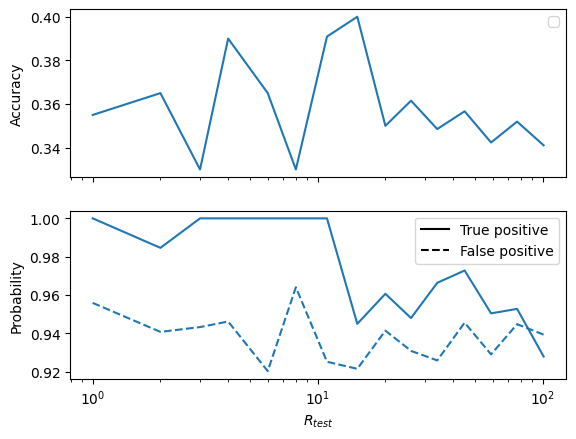

In [2]:
from networks import HebbFeatureLayer
from data import GenRecogClassifyData
from plotting import plot_generalization, get_recog_positive_rates

d = 50
Nh = 16
Ny = 1
Nx = 512

Tmul = 20
Tmin = 200
P = 0.5 # Probability of repeat
noMultiRep = True

net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
pretrained_weights = "results\\tensor_board_logs\\results\\HebbFeature_freezehebbff.pkl"
net.load(pretrained_weights)
img_dataset = "publish/conv/BradyOliva2008_UniqueObjects_ResNet18.pkl"
images = torch.load(img_dataset)
dummyClasses = torch.zeros(images.shape[0],1)
sampleSpace = TensorDataset(images, dummyClasses)
generator = GenRecogClassifyData(sampleSpace=sampleSpace)
    
def generate_recog_data_batch(T,d,R,P,multiRep,batchSize,**kwargs):
    x,y = generator(T, R, P, batchSize, multiRep).tensors
    return TensorDataset(x, y[..., 0:1])

if type(net) == HebbFeatureLayer:
    assert images.shape[1] == Nx # sanity check

gen_data = lambda R: generate_recog_data_batch(T=max(Tmin, R*Tmul), 
                                                   d=d, 
                                                   R=R, 
                                                   P=P, 
                                                   softLabels=False,
                                                   interleave=True, 
                                                   multiRep=(not noMultiRep), 
                                                   batchSize=None,
                                                   xDataVals='+-',
                                                   device='cpu')

testR, testAcc, truePosRate, falsePosRate = get_recog_positive_rates(net, gen_data)
plot_generalization(testR, testAcc, truePosRate, falsePosRate)